# 04 · V2 explanations, errors and uncertainty

## 1. Explain the actual deployed artifact
We load the same verified artifact as the Streamlit app. Explanations describe its associations, not causal valuation rules. A feature that predicts price well does not establish what a renovation or location change would cause.

Holdout analysis is performed after selection. It identifies limitations and hypotheses for a future experiment, not opportunities to refit against this test set.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import INPUT_COLUMNS, VERSION
from src.inference import load_artifacts
model, metadata = load_artifacts()
report = json.loads((ROOT / 'reports/evaluation.json').read_text())
assert report['project_version'] == VERSION
pd.set_option('display.max_columns', 10)
pd.set_option('display.float_format', '{:,.3f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

test = pd.read_csv(ROOT / 'data/processed/test_predictions.csv', parse_dates=['INSTANCE_DATE'])
sample = test.sample(min(400,len(test)), random_state=42)

## 2. Permutation importance in total AED
Shuffle one raw input at a time and measure the increase in MAE. This evaluates the entire pipeline, including target inversion and segment routing. In a unit-price model, shuffling surface also changes the multiplication back to total price; its importance includes that structural effect.

Area and project can substitute for each other, so correlated features share credit. Shuffling creates unrealistic combinations. Three repeats over a fixed 400-row sample provide a readable diagnostic, not precise population-level importance.

,feature,MAE_increase_AED,repeat_std
0,ACTUAL_AREA,"1,069,669.800","119,853.885"
2,AREA_EN,"261,567.514","52,904.136"
7,PROJECT_EN,"190,661.889","47,508.141"
3,PROP_SB_TYPE_EN,"122,913.805","21,288.693"
4,ROOMS_EN,"65,290.697","10,662.308"
5,IS_OFFPLAN_EN,"26,384.219","9,261.595"
6,IS_FREE_HOLD_EN,"2,602.713",23.188
1,INSTANCE_DATE,0.000,0.000


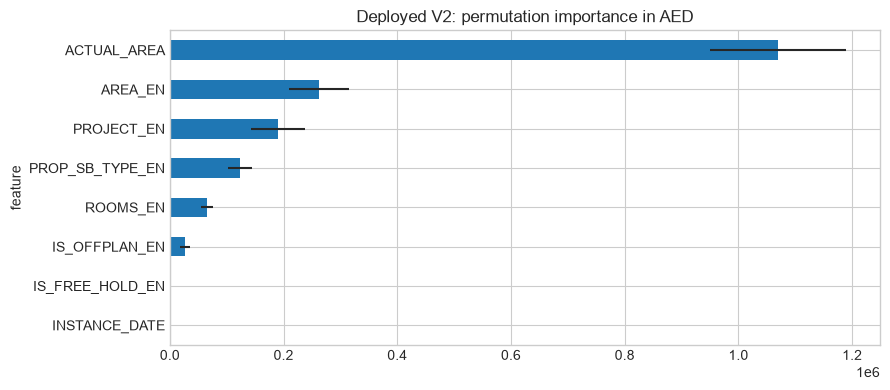

In [2]:
from sklearn.inspection import permutation_importance
result = permutation_importance(model, sample[INPUT_COLUMNS], sample.TRANS_VALUE, scoring='neg_mean_absolute_error', n_repeats=3, random_state=42, n_jobs=1)
importance = pd.DataFrame({'feature':INPUT_COLUMNS,'MAE_increase_AED':result.importances_mean,'repeat_std':result.importances_std}).sort_values('MAE_increase_AED',ascending=False)
display(importance)
importance.sort_values('MAE_increase_AED').plot.barh(x='feature',y='MAE_increase_AED',xerr='repeat_std',legend=False,figsize=(9,4))
plt.title('Deployed V2: permutation importance in AED'); plt.tight_layout(); plt.show()
importance.to_csv(ROOT / 'reports/feature_importance.csv',index=False)

## 3. Individual prediction and local sensitivity
Inspect one observed/predicted price and its empirical range. Varying surface with other fields fixed reveals local model behavior, but is not a causal experiment: changing size may also imply a different layout or room count.

In [3]:
from src.inference import predict_property
example = sample[INPUT_COLUMNS].iloc[[0]].copy()
estimate = predict_property(model, metadata, example.iloc[0].to_dict())
display(example)
print(f'Observed AED {sample.iloc[0].TRANS_VALUE:,.0f}; predicted AED {estimate.price_aed:,.0f}')
print(f'Empirical range AED {estimate.lower_aed:,.0f} – {estimate.upper_aed:,.0f}')
variants = pd.concat([example]*3, ignore_index=True)
variants['ACTUAL_AREA'] = float(example.ACTUAL_AREA.iloc[0])*np.array([.9,1.,1.1])
variants['predicted_price'] = model.predict(variants[INPUT_COLUMNS])
display(variants[['ACTUAL_AREA','predicted_price']])

,ACTUAL_AREA,INSTANCE_DATE,AREA_EN,PROP_SB_TYPE_EN,ROOMS_EN,IS_OFFPLAN_EN,IS_FREE_HOLD_EN,PROJECT_EN
4871,39.080,2026-08-04 13:13:48,BUSINESS BAY,Flat,Studio,Ready,Free Hold,URBAN OASIS


Observed AED 990,000; predicted AED 1,036,373
Empirical range AED 809,974 – 1,326,054


,ACTUAL_AREA,predicted_price
0,35.172,"951,407.823"
1,39.080,"1,036,373.018"
2,42.988,"1,114,162.212"


## 4. SHAP in the correct target units
SHAP decomposes a prediction relative to a reference value. Explain the estimator actually used for this property (a specialist if routed, otherwise global). CatBoost's native SHAP handles its categorical processing; other supported trees use TreeExplainer.

The additive contributions are in the estimator's **training-target units**: AED for direct price, log1p(AED) for the log formulation, or AED/m² for the unit-price formulation. Do not label log or unit-price SHAP values as total-AED effects. For a fixed individual surface, multiplying unit-price contributions by that surface could decompose that particular total prediction, but would not isolate the causal effect of surface. The plots here retain native units and check reconstruction.

Explanation units: AED/m²


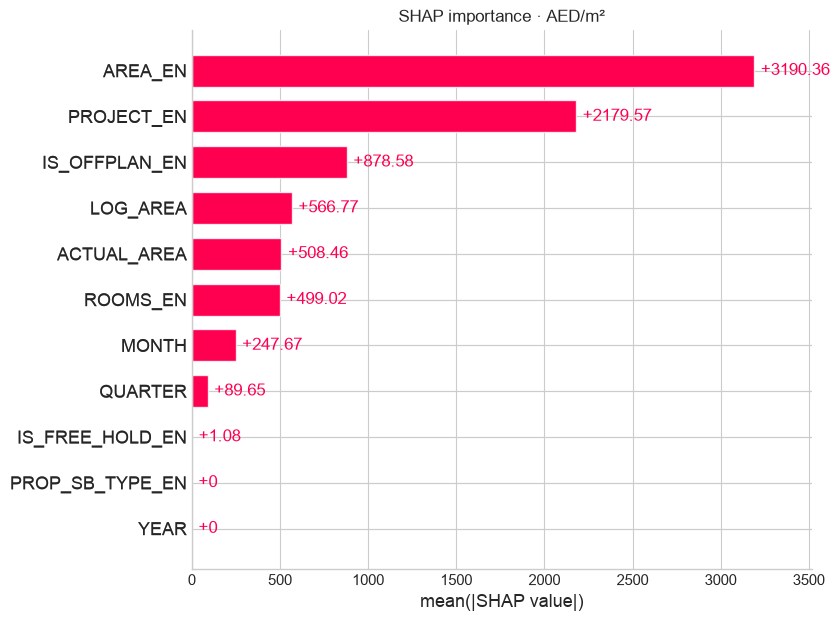

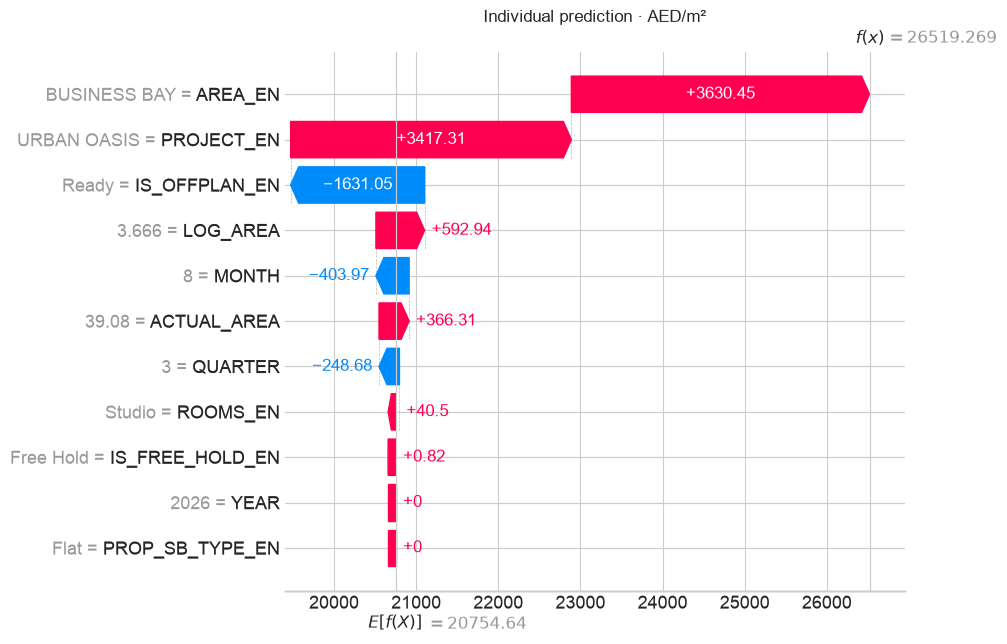

In [4]:
import importlib.util
from src.estimators import SegmentedPriceModel, NativeCatRegressor
explained_model = model
if isinstance(model, SegmentedPriceModel):
    explained_model = (model.specialists or {}).get(example.PROP_SB_TYPE_EN.iloc[0], model.global_model)
pipeline = explained_model.pipeline_
estimator = pipeline.named_steps['regressor']
units = {'direct':'AED','log':'log1p(AED)','per_sqm':'AED/m²'}[explained_model.formulation]
print('Explanation units:', units)
if importlib.util.find_spec('shap') is None:
    print('Optional SHAP is not installed; permutation importance and local sensitivity remain available.')
else:
    import shap
    shap_rows = sample[INPUT_COLUMNS]
    if isinstance(model, SegmentedPriceModel) and example.PROP_SB_TYPE_EN.iloc[0] in (model.specialists or {}):
        shap_rows = shap_rows.loc[shap_rows.PROP_SB_TYPE_EN.eq(example.PROP_SB_TYPE_EN.iloc[0])]
    transformed = pipeline.named_steps['preprocess'].transform(shap_rows.iloc[:30])
    if isinstance(estimator, NativeCatRegressor):
        from catboost import Pool
        pool = Pool(transformed, cat_features=estimator.cat_features)
        values = estimator.model_.get_feature_importance(pool, type='ShapValues')
        explanation = shap.Explanation(values=values[:,:-1], base_values=values[:,-1], data=transformed.to_numpy(), feature_names=list(transformed.columns))
    else:
        names = pipeline.named_steps['preprocess'].named_steps['encode'].get_feature_names_out()
        if hasattr(estimator, 'coef_'):
            explanation = shap.LinearExplainer(estimator, transformed)(transformed)
        elif hasattr(estimator, 'constant_'):
            explanation = None
            print('A constant baseline has no feature-dependent SHAP contributions.')
        else:
            explanation = shap.TreeExplainer(estimator)(transformed)
        if explanation is not None:
            explanation.feature_names = list(names)
    if explanation is not None:
        reconstructed = explanation.base_values + explanation.values.sum(axis=1)
        np.testing.assert_allclose(reconstructed, estimator.predict(transformed), rtol=1e-4, atol=1e-3)
        shap.plots.bar(explanation,max_display=12,show=False); plt.title('SHAP importance · '+units); plt.show()
        shap.plots.waterfall(explanation[0],max_display=12,show=False); plt.title('Individual prediction · '+units); plt.show()

## 5. Where does the model fail?
Examine property subtype, neighborhood, price band, rooms and completion status. Positive bias means average overprediction. Coverage measures how often observed prices fell inside the empirical interval.

Price bands use observed targets only for post-selection error analysis; they never enter the predictor. Display area results with at least 100 holdout records to reduce small-sample noise. Counts are essential: rare-category R² is unstable, and a good global score can hide poor villa or luxury performance.

PROP_SB_TYPE_EN


,group,rows,MAE,RMSE,R2,bias_AED,interval_coverage
0,Flat,16998,"248,241.301","1,035,303.151",0.809,"-44,464.465",0.886
1,Villa,1075,"751,734.690","6,101,899.014",0.436,"-349,932.845",0.846
2,Residential Flats,12,"21,999,902.621","51,307,261.485",0.379,"-18,905,996.362",0.417
3,Residential / Attached Villas,9,"164,467.711","242,351.396",0.618,"-58,324.924",0.778
4,Residential / Villas,3,"10,850,306.873","17,735,920.278",-1.855,"-10,850,306.873",0.667


AREA_EN


,group,rows,MAE,RMSE,R2,bias_AED,interval_coverage
24,DUBAI HILLS,176,"1,676,224.781","13,218,100.685",0.552,"-780,507.104",0.750
15,BURJ KHALIFA,262,"1,152,348.683","2,574,445.198",0.732,"-188,268.734",0.668
37,Palm Jabal Ali,132,"987,798.773","1,387,866.442",0.798,"-287,136.432",0.689
11,DUBAI MARINA,335,"873,441.012","1,521,352.873",0.576,"-83,682.267",0.436
6,BUSINESS BAY,531,"825,176.592","3,084,379.127",0.723,"-456,332.023",0.819
45,Wadi Al Safa 3,105,"714,781.208","1,031,184.741",0.906,"299,771.280",0.543
41,Hadaeq Sheikh Mohammed Bin Rashid,115,"686,810.851","2,467,375.717",0.842,"-95,739.112",0.913
27,JUMEIRAH LAKES TOWERS,167,"431,441.435","1,216,498.837",0.484,"254,063.254",0.749
44,DUBAI MARITIME CITY,105,"409,152.045","664,764.750",0.706,"-312,745.507",0.914
23,Palm Deira,177,"404,646.106","855,195.024",0.808,"6,060.521",0.932


price_band


,group,rows,MAE,RMSE,R2,bias_AED,interval_coverage
0,<1M,7921,"118,687.300","371,832.215",-3.014,"71,415.993",0.887
1,1–2M,5721,"142,574.900","218,120.163",0.318,-240.469,0.919
2,2–5M,3808,"370,694.507","534,297.349",0.547,"-148,108.643",0.865
3,5–10M,466,"1,178,007.692","1,642,215.519",-0.772,"-664,632.846",0.687
4,10M+,181,"8,891,718.341","21,932,504.035",0.369,"-5,980,808.431",0.409


ROOMS_EN


,group,rows,MAE,RMSE,R2,bias_AED,interval_coverage
0,Studio,6499,"61,483.072","121,376.738",0.594,"3,402.068",0.946
1,1 B/R,6424,"193,106.787","365,873.641",0.642,"-3,280.491",0.862
2,2 B/R,3281,"404,689.297","1,214,887.352",0.673,"-110,857.963",0.842
3,3 B/R,1150,"836,890.489","2,241,172.530",0.766,"-350,193.936",0.807
4,4 B/R,529,"1,203,664.067","3,462,808.256",0.772,"-268,262.286",0.849
5,5 B/R,161,"1,046,000.554","1,828,013.024",0.734,"-401,298.151",0.733
6,NaN,42,"8,198,862.154","27,911,770.547",0.499,"-5,767,949.645",0.571
7,PENTHOUSE,7,"940,453.784","1,685,324.927",-5.422,"885,771.653",0.714
8,6 B/R,4,"59,841,123.887","99,476,037.716",0.015,"-45,986,878.532",0.250


IS_OFFPLAN_EN


,group,rows,MAE,RMSE,R2,bias_AED,interval_coverage
0,Off-Plan,13271,"219,641.542","1,051,108.843",0.824,"-91,964.149",0.925
1,Ready,4826,"499,562.264","3,971,412.873",0.546,"-35,531.778",0.768


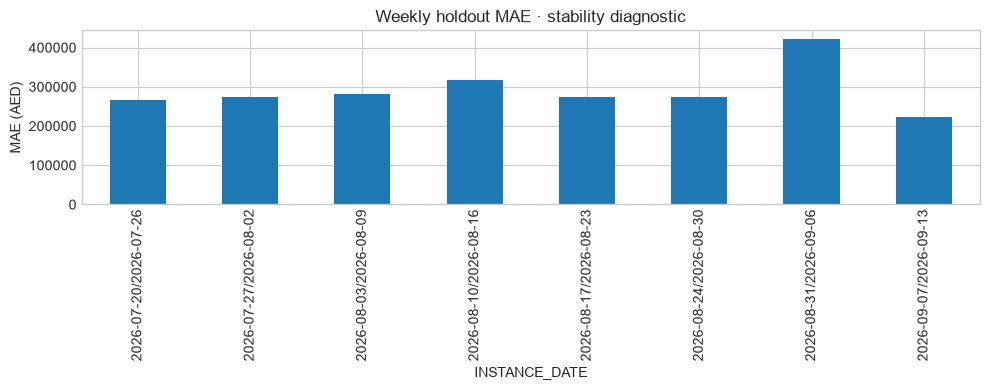

In [5]:
for name in ['PROP_SB_TYPE_EN','AREA_EN','price_band','ROOMS_EN','IS_OFFPLAN_EN']:
    table = pd.read_csv(ROOT / f'reports/v2_errors_{name}.csv')
    if name == 'AREA_EN':
        table = table.loc[table.rows.ge(100)].sort_values('MAE',ascending=False)
    print(name)
    display(table.head(12))
residuals = test.assign(absolute_error=(test.predicted_price-test.TRANS_VALUE).abs())
weekly = residuals.groupby(residuals.INSTANCE_DATE.dt.to_period('W')).absolute_error.mean()
weekly.plot.bar(figsize=(10,4),title='Weekly holdout MAE · stability diagnostic')
plt.ylabel('MAE (AED)'); plt.tight_layout(); plt.show()

## 6. Communicate uncertainty honestly
The interval is calibrated on earlier residuals and targets nominal 90% coverage, not guaranteed confidence. Market shifts, unseen projects and rare subtypes can change coverage. A narrow range is not proof of a reliable estimate; compare empirical coverage and error by subgroup.

Explanations cannot reveal missing information such as view, floor, condition or ownership share. Rare Residential labels still need scope review. The next scientific step is independent later-period validation, not repeated tuning on the known holdout.